# Explainability of churn customers
 
 The modeling notebook produces churn predictions but does not explain why individual customers were flagged. This notebook uses SHAP to identify which features drove each prediction, and by how much. By the end, a non-technical stakeholder should understand the key churn drivers and be able to design targeted retention actions for different customer profiles.

In [1]:
import numpy as np 
import pandas as pd 
import joblib 
import shap 
import matplotlib.pyplot as plt

In [2]:
X_test = np.load("../models/X_test_processed.npy")
y_test = np.load("../models/y_test.npy")
xgboost_churn_model =joblib.load("../models/xgboost_churn_model.pkl") 
xgboost_threshold= joblib.load("../models/xgboost_threshold.pkl") 
preprocessor = joblib.load("../models/preprocessor.pkl")


In [3]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['num__tenure' 'num__MonthlyCharges' 'num__TotalCharges'
 'cat__gender_Female' 'cat__gender_Male' 'cat__Partner_No'
 'cat__Partner_Yes' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__PhoneService_No' 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No' 'cat__StreamingMovies_No internet service'
 'cat__StreamingMovies_Yes' 'cat__Contract_Month-to-month'
 'cat__Contr

In [4]:
explainer = shap.TreeExplainer(xgboost_churn_model)
shap_values = explainer.shap_values(X_test)
print(shap_values.shape)

(1409, 45)


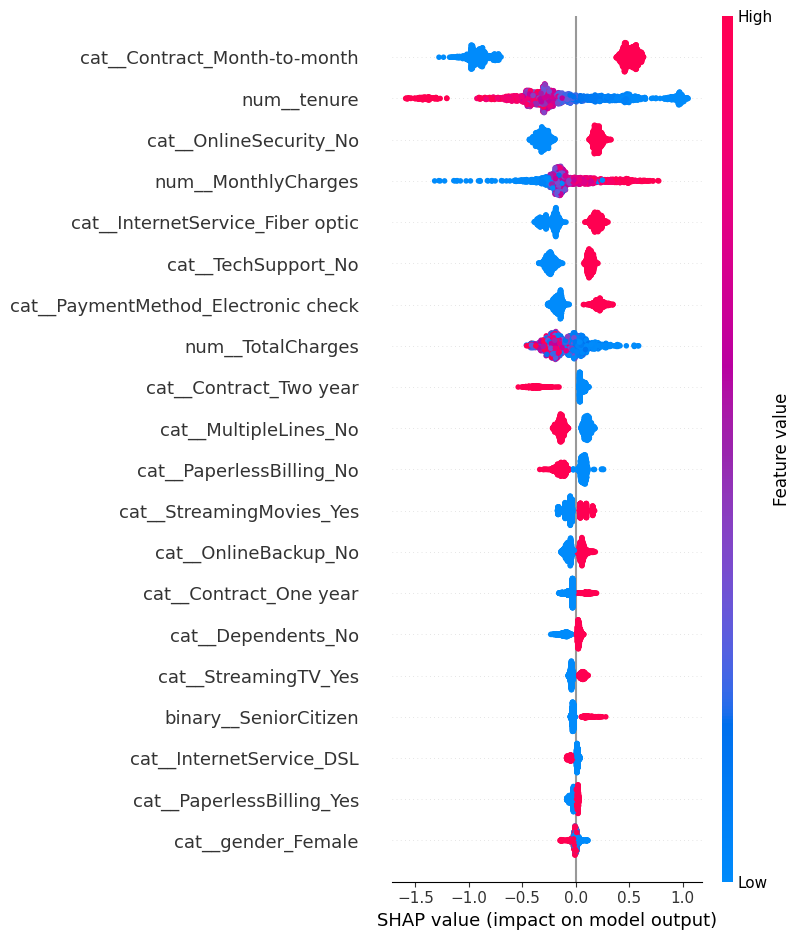

In [5]:
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

# Interpretaion 

-Customers on month-to-month contracts represent the strongest churn signal in the model. The higher the concentration of this contract type, the greater the predicted probability of churn — indicating that contract flexibility is a key driver of customer attrition.

-Early-tenure customers, particularly those who recently signed their contracts, show the highest churn probability. This suggests that the first months of the customer relationship are the most critical retention window.

-Monthly charges show a clear positive relationship with churn risk. Customers facing higher bills are significantly more likely to leave, pointing to pricing sensitivity as a key factor in retention strategy.

In [6]:
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.savefig("../reports/shap_summary_churn.png", bbox_inches="tight", dpi=150)
plt.close()
print("Plot saved.")

Plot saved.


# Retention actions 

-To reduce early churn, the company should introduce onboarding incentives for new customers — such as discounted rates or service upgrades during the first three months — to increase perceived value before the first cancellation window.

-To reduce month-to-month contract risk, the company should make quarterly or semi-annual contracts more attractive through competitive pricing or exclusive benefits, encouraging customers to commit beyond a single month and giving the retention team more time to act on at-risk signals.